In [1]:
import numpy as np

def softmax(logits, temperature=1.0):
    scaled_logits = logits / temperature
    exp_vals = np.exp(scaled_logits - np.max(scaled_logits))  # stability
    return exp_vals / np.sum(exp_vals)

logits = np.array([2.0, 1.0, 0.1])

temperatures = [0.1, 0.5, 1.0, 2.0, 5.0]

for T in temperatures:
    probs = softmax(logits, T)
    print(f"Temperature={T} → {probs}")


Temperature=0.1 → [9.99954597e-01 4.53978684e-05 5.60254205e-09]
Temperature=0.5 → [0.86377712 0.11689952 0.01932336]
Temperature=1.0 → [0.65900114 0.24243297 0.09856589]
Temperature=2.0 → [0.50168776 0.30428901 0.19402324]
Temperature=5.0 → [0.39958568 0.32715309 0.27326123]


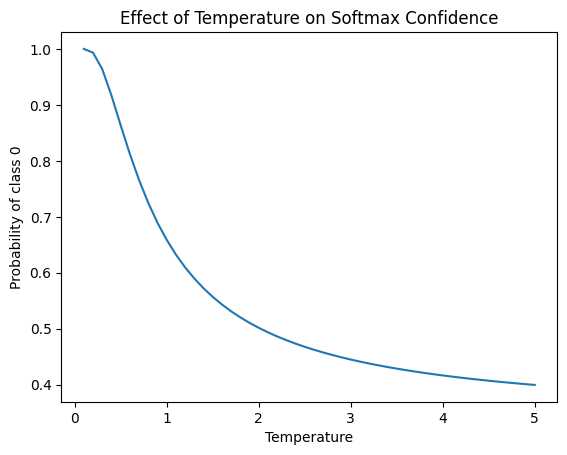

In [2]:
import matplotlib.pyplot as plt

temps = np.linspace(0.1, 5, 50)
class0_probs = [softmax(logits, T)[0] for T in temps]

plt.plot(temps, class0_probs)
plt.xlabel("Temperature")
plt.ylabel("Probability of class 0")
plt.title("Effect of Temperature on Softmax Confidence")
plt.show()


In [ ]:
import torch
import torch.nn.functional as F

def distillation_loss(student_logits, teacher_logits, labels,
                      temperature=4.0, alpha=0.7):

    # Soft targets
    teacher_probs = F.softmax(teacher_logits / temperature, dim=1)
    student_log_probs = F.log_softmax(student_logits / temperature, dim=1)

    kd_loss = F.kl_div(
        student_log_probs,
        teacher_probs,
        reduction="batchmean"
    ) * (temperature ** 2)

    ce_loss = F.cross_entropy(student_logits, labels)

    return alpha * kd_loss + (1 - alpha) * ce_loss


In [ ]:
###Possible training loop

teacher.eval()

for x, y in dataloader:
    with torch.no_grad():
        teacher_logits = teacher(x)

    student_logits = student(x)

    loss = distillation_loss(
        student_logits,
        teacher_logits,
        y,
        temperature=4.0,
        alpha=0.7
    )

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
